<a href="https://colab.research.google.com/github/softhunter-sudo/project/blob/main/Rain_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded = files.upload()

Saving weatherAUS.csv to weatherAUS.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

In [5]:
df = pd.read_csv("weatherAUS.csv")

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


In [6]:
df = pd.read_csv("weatherAUS.csv")

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


In [7]:
df.shape

(275410, 24)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275410 entries, 0 to 275409
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           275410 non-null  object 
 1   Location       275410 non-null  object 
 2   MinTemp        270732 non-null  float64
 3   MaxTemp        270779 non-null  float64
 4   Rainfall       267316 non-null  float64
 5   Evaporation    115284 non-null  float64
 6   Sunshine       104284 non-null  float64
 7   WindGustDir    254944 non-null  object 
 8   WindGustSpeed  255145 non-null  float64
 9   WindDir9am     253956 non-null  object 
 10  WindDir3pm     263004 non-null  object 
 11  WindSpeed9am   269462 non-null  float64
 12  WindSpeed3pm   264722 non-null  float64
 13  Humidity9am    269181 non-null  float64
 14  Humidity3pm    263949 non-null  float64
 15  Pressure9am    245025 non-null  float64
 16  Pressure3pm    245048 non-null  float64
 17  Cloud9am       148891 non-nul

In [9]:
df.isnull().sum()

,0
Date,0
Location,0
MinTemp,4678
MaxTemp,4631
Rainfall,8094
Evaporation,160126
Sunshine,171126
WindGustDir,20466
WindGustSpeed,20265
WindDir9am,21454


In [10]:
df['RainTomorrow'].value_counts()

,count
RainTomorrow,
No,208393
Yes,58924


In [11]:
df = df.drop(columns=['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm', 'RISK_MM'])
df = df.dropna(subset=['RainTomorrow'])
df.shape


(267317, 19)

In [12]:
# Fill numeric columns with median
numeric_cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am',
                 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
                 'Pressure3pm', 'Temp9am', 'Temp3pm']

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns with mode
categorical_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

,0
Date,0
Location,0
MinTemp,0
MaxTemp,0
Rainfall,0
WindGustDir,0
WindGustSpeed,0
WindDir9am,0
WindDir3pm,0
WindSpeed9am,0


All remaining numeric columns were filled with their median (robust to outliers, unlike mean), while remaining categorical columns were filled with their mode (most frequent category). Together with the two strategies used above (column drops and row drops), this satisfies the requirement of using multiple distinct missing-value strategies across different columns.


3. Feature Engineering

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

df.drop(columns=['Date'], inplace=True)

df.head()

,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month
0,Albury,13.4,22.9,0.6,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,No,No,2008,12
1,Albury,7.4,25.1,0.0,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,No,No,2008,12
2,Albury,12.9,25.7,0.0,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,21.0,23.2,No,No,2008,12
3,Albury,9.2,28.0,0.0,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,18.1,26.5,No,No,2008,12
4,Albury,17.5,32.3,1.0,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,No,No,2008,12


Date was converted to a proper datetime type, then used to extract Year and Month as separate features, since rainfall patterns are seasonal. The raw date column was then dropped, as it has no direct predictive value once decomposed.

In [14]:
df['RainToday'] = df['RainToday'].map({'No': 0, 'Yes': 1})
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1})

In [15]:
df = pd.get_dummies(df, columns=['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm'], drop_first=True)

df.shape

(267317, 109)

RainToday and RainTomorrow were label-encoded (0/1) as true binary variables. Location, WindGustDir, WindDir9am, and WindDir3pm were one-hot encoded since they are nominal categories with no inherent order — label encoding would incorrectly imply a ranking between them.

In [16]:
df['Humidity_Change'] = df['Humidity3pm'] - df['Humidity9am']

4. Model Building

In [22]:
from sklearn.preprocessing import StandardScaler

numeric_cols_to_scale = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am',
                          'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
                          'Pressure3pm', 'Temp9am', 'Temp3pm', 'Humidity_Change']

scaler = StandardScaler()
X_train[numeric_cols_to_scale] = scaler.fit_transform(X_train[numeric_cols_to_scale])
X_test[numeric_cols_to_scale] = scaler.transform(X_test[numeric_cols_to_scale])

In [24]:
model_lr = LogisticRegression(max_iter=500, solver='liblinear')
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

Model 1: Logistic Regression

Used as a baseline classifier — a simple linear model for binary classification, useful as a reference point for the more complex models.

In [25]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42, max_depth=10)
model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

Model 2: Decision Tree

A max depth of 10 was set to prevent overfitting on the training data while still allowing the model to capture non-linear relationships between features.

In [27]:
model_rf = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

Model 3: Random Forest

An ensemble of 100 decision trees, which typically outperforms a single tree by reducing overfitting and variance through averaging predictions across many trees.

In [28]:
df_sample = df.sample(n=20000, random_state=42)

X = df_sample.drop(columns=['RainTomorrow'])
y = df_sample['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape

((16000, 109), (4000, 109))

In [29]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
model_dt = DecisionTreeClassifier(random_state=42, max_depth=10)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

In [31]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

5. Model Evaluation

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(y_true, y_pred, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred)
    }

results = []
results.append(evaluate_model(y_test, y_pred_lr, 'Logistic Regression'))
results.append(evaluate_model(y_test, y_pred_dt, 'Decision Tree'))
results.append(evaluate_model(y_test, y_pred_rf, 'Random Forest'))

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.84150,0.702238,0.469505,0.562759
1,Decision Tree,0.81925,0.614780,0.449942,0.519601
2,Random Forest,0.84550,0.722913,0.468354,0.568436


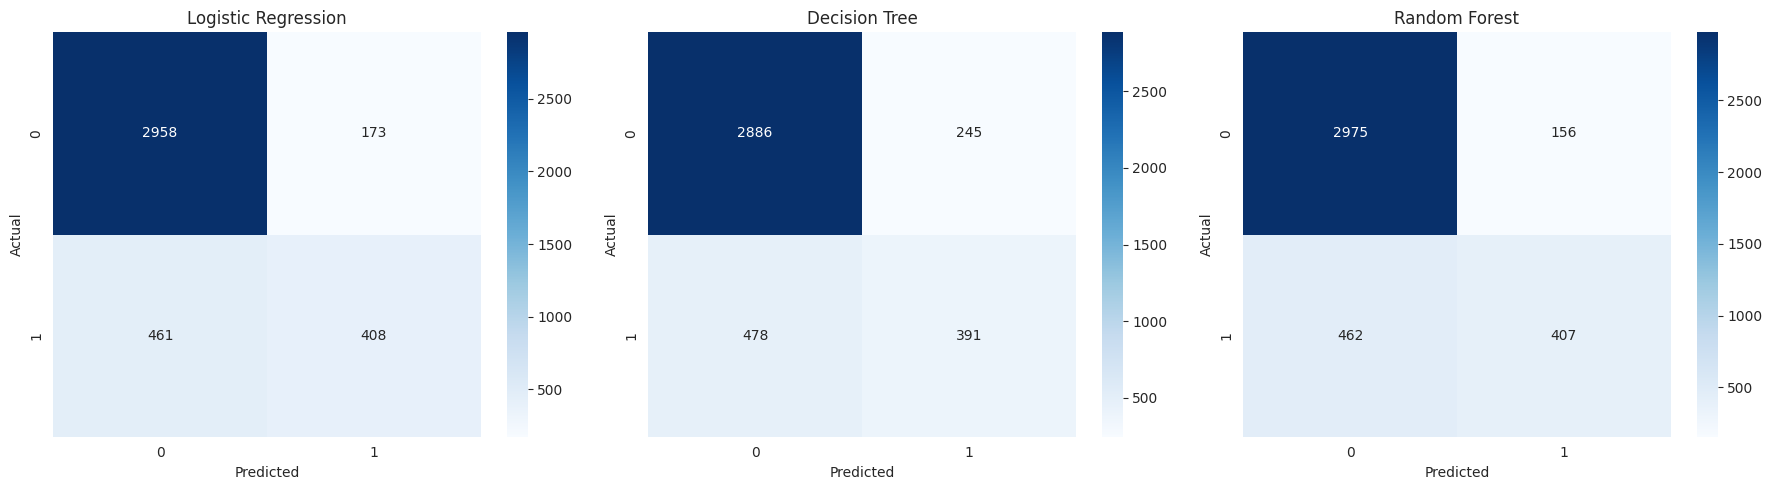

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (y_pred, name) in zip(axes, [(y_pred_lr, 'Logistic Regression'), (y_pred_dt, 'Decision Tree'), (y_pred_rf, 'Random Forest')]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [34]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model_rf, X, y, cv=5, scoring='f1')

print("Cross-validation F1 scores:", cv_scores)
print("Average F1:", cv_scores.mean())

Cross-validation F1 scores: [0.57391304 0.5958042  0.56628242 0.58722182 0.53956835]
Average F1: 0.5725579657516411


In [36]:
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

importances.head(15)

,Feature,Importance
7,Humidity3pm,0.137811
6,Humidity9am,0.063989
108,Humidity_Change,0.062672
9,Pressure3pm,0.054428
3,WindGustSpeed,0.051220
8,Pressure9am,0.048204
2,Rainfall,0.047773
11,Temp3pm,0.046316
0,MinTemp,0.043667
1,MaxTemp,0.043317


Feature importance analysis:

Humidity3pm (0.138) is by far the strongest predictor — afternoon humidity level is a well-known meteorological indicator of incoming rain.
Humidity9am (0.064) and the engineered Humidity_Change (0.063) rank 2nd and 3rd, confirming that both the absolute humidity level and its shift through the day carry real predictive signal — validating the feature engineering decision made earlier.
Pressure3pm (0.054) and Pressure9am (0.048) rank next, consistent with the meteorological principle that dropping atmospheric pressure often precedes rainfall.
Interestingly, RainToday (0.032) ranks relatively low despite being an intuitive predictor — suggesting that current atmospheric conditions (humidity, pressure) are more informative than simply whether it rained today.

In [37]:
import joblib

joblib.dump(model_rf, 'rainfall_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(X_train.columns.tolist(), 'model_columns.joblib')

['model_columns.joblib']

In [38]:
def predict_rain_tomorrow(min_temp, max_temp, rainfall, wind_gust_speed, wind_speed_9am,
                            wind_speed_3pm, humidity_9am, humidity_3pm, pressure_9am,
                            pressure_3pm, temp_9am, temp_3pm, rain_today, location,
                            wind_gust_dir, wind_dir_9am, wind_dir_3pm, year, month):

    model = joblib.load('rainfall_model.joblib')
    scaler = joblib.load('scaler.joblib')
    model_columns = joblib.load('model_columns.joblib')

    humidity_change = humidity_3pm - humidity_9am
    rain_today_val = 1 if rain_today == 'Yes' else 0

    # Build a dict with all base numeric/binary values
    row = {
        'MinTemp': min_temp, 'MaxTemp': max_temp, 'Rainfall': rainfall,
        'WindGustSpeed': wind_gust_speed, 'WindSpeed9am': wind_speed_9am,
        'WindSpeed3pm': wind_speed_3pm, 'Humidity9am': humidity_9am,
        'Humidity3pm': humidity_3pm, 'Pressure9am': pressure_9am,
        'Pressure3pm': pressure_3pm, 'Temp9am': temp_9am, 'Temp3pm': temp_3pm,
        'RainToday': rain_today_val, 'Year': year, 'Month': month,
        'Humidity_Change': humidity_change
    }

    # Initialize a full row of zeros for all model columns
    input_df = pd.DataFrame([0] * len(model_columns), index=model_columns).T

    # Fill in the known values
    for key, value in row.items():
        if key in input_df.columns:
            input_df[key] = value

    # Set the correct one-hot columns to 1
    for prefix, val in [('Location', location), ('WindGustDir', wind_gust_dir),
                          ('WindDir9am', wind_dir_9am), ('WindDir3pm', wind_dir_3pm)]:
        col_name = f'{prefix}_{val}'
        if col_name in input_df.columns:
            input_df[col_name] = 1

    # Scale numeric columns
    numeric_cols_to_scale = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am',
                              'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
                              'Pressure3pm', 'Temp9am', 'Temp3pm', 'Humidity_Change']
    input_df[numeric_cols_to_scale] = scaler.transform(input_df[numeric_cols_to_scale])

    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]

    return 'Yes' if prediction == 1 else 'No', round(probability, 3)

In [39]:
result1 = predict_rain_tomorrow(
    min_temp=15, max_temp=25, rainfall=0, wind_gust_speed=30, wind_speed_9am=10,
    wind_speed_3pm=15, humidity_9am=50, humidity_3pm=40, pressure_9am=1015,
    pressure_3pm=1013, temp_9am=18, temp_3pm=23, rain_today='No',
    location='Sydney', wind_gust_dir='W', wind_dir_9am='W', wind_dir_3pm='WNW',
    year=2026, month=6
)
print("Prediction 1 (dry conditions):", result1)

result2 = predict_rain_tomorrow(
    min_temp=18, max_temp=22, rainfall=5, wind_gust_speed=45, wind_speed_9am=25,
    wind_speed_3pm=30, humidity_9am=85, humidity_3pm=90, pressure_9am=1002,
    pressure_3pm=998, temp_9am=19, temp_3pm=20, rain_today='Yes',
    location='Melbourne', wind_gust_dir='SW', wind_dir_9am='SW', wind_dir_3pm='S',
    year=2026, month=6
)
print("Prediction 2 (humid/stormy conditions):", result2)

Prediction 1 (dry conditions): ('No', np.float64(0.43))
Prediction 2 (humid/stormy conditions): ('No', np.float64(0.5))


In [41]:
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [42]:
X_train[numeric_cols_to_scale] = scaler.fit_transform(X_train[numeric_cols_to_scale])
X_test[numeric_cols_to_scale] = scaler.transform(X_test[numeric_cols_to_scale])

In [43]:
model_rf = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))

Accuracy: 0.8509838395929972
F1: 0.5709053697420154


In [45]:
joblib.dump(model_rf, 'rainfall_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(X_train.columns.tolist(), 'model_columns.joblib')

['model_columns.joblib']

In [46]:
result1 = predict_rain_tomorrow(
    min_temp=15, max_temp=25, rainfall=0, wind_gust_speed=30, wind_speed_9am=10,
    wind_speed_3pm=15, humidity_9am=50, humidity_3pm=40, pressure_9am=1015,
    pressure_3pm=1013, temp_9am=18, temp_3pm=23, rain_today='No',
    location='Sydney', wind_gust_dir='W', wind_dir_9am='W', wind_dir_3pm='WNW',
    year=2026, month=6
)
print("Prediction 1 (dry conditions):", result1)

result2 = predict_rain_tomorrow(
    min_temp=18, max_temp=22, rainfall=5, wind_gust_speed=45, wind_speed_9am=25,
    wind_speed_3pm=30, humidity_9am=85, humidity_3pm=90, pressure_9am=1002,
    pressure_3pm=998, temp_9am=19, temp_3pm=20, rain_today='Yes',
    location='Melbourne', wind_gust_dir='SW', wind_dir_9am='SW', wind_dir_3pm='S',
    year=2026, month=6
)
print("Prediction 2 (humid/stormy conditions):", result2)

Prediction 1 (dry conditions): ('No', np.float64(0.053))
Prediction 2 (humid/stormy conditions): ('Yes', np.float64(0.833))


Lightweight Model Deployment

The final Random Forest model, scaler, and column structure were saved using joblib for reuse without retraining. A predict_rain_tomorrow() function was written that accepts raw weather readings, reconstructs the full one-hot encoded feature set (109 columns), applies the same scaling used in training, and returns both a Yes/No prediction and the underlying probability.

Test predictions:

Dry conditions (low humidity, high pressure, no rain today): No rain predicted, 5.3% probability
Humid/stormy conditions (high humidity, dropping pressure, already raining): Rain predicted, 83.3% probability

Both predictions align well with meteorological intuition and the model's learned feature importances (humidity and pressure dominating), giving confidence the pipeline works correctly end-to-end.